In [2]:
import pandas as pd
import torch
import torch.nn.functional as F
import numpy as np
import h5py
import os
import sys
from tqdm import tqdm

In [3]:
# set path to outside directory

from network import FourLayerDinoNetwork, TwoLayerDinoNetwork, FrameAwareDinoNetwork, OneLayerDinoNetwork
#get out 2 directories
sys.path.append(os.path.abspath(os.path.join(os.path.dirname(os.getcwd()), "../")))
from dataloader import get_dino_dataset,create_val_train_splits, get_dataset
from eval_helper import run_experiment, grid_search_hyperparameters, time_stamp_phases
from Smoothing import majority_vote_past, majority_vote_future, thresholded_argmax, majority_vote_bidirectional, TemporalSmoother

In [4]:
smoother = TemporalSmoother()

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = FrameAwareDinoNetwork().to(device)
model.load_state_dict(torch.load('/code/jjiang23/pathml/aim2_balance/models/DinoClassifer/results/frame_train_set_v3/best_model.pth'))
model.eval()

/tmp/ipykernel_3568539/3669164522.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('/code/jjiang23/pathml/aim2_balance/models/DinoClassif

FrameAwareDinoNetwork(
  (model): Sequential(
    (0): Linear(in_features=1025, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.7, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.7, inplace=False)
    (8): Linear(in_features=64, out_features=5, bias=True)
  )
)

In [6]:
def get_data(path, frame_aware=False):
    features,labels, fps_list=get_dataset(path, "dinov3_features",frame_aware=frame_aware)

    labels = [label.tolist() for label in labels]
    model_outputs =[]
    with torch.no_grad():
        for i in range(len(features)):
            feature = features[i].to(device)
            output = model(feature)
            model_outputs.append(output.cpu())
    return labels, fps_list, model_outputs

In [8]:
train_labels, train_fps_list, train_model_outputs = get_data("/code/jjiang23/pathml/aim2_balance/processed_files/train_set.txt", frame_aware=True)

grid_search_hyperparameters(train_model_outputs, train_fps_list, train_labels)

Processing videos: 100%|██████████| 104/104 [00:00<00:00, 104.18it/s]


Total truth passes: 245, Total truth fails: 44
Params: {'arg_max_fun': None, 'smoothing_window': 10, 'smoothing_function': <function majority_vote_bidirectional at 0x7fe1e86cfb00>, 'timestamp_window': 5}, F1 Score: 0.8835268228235946, number missing_info: 43


Processing videos: 100%|██████████| 104/104 [00:01<00:00, 103.85it/s]


Total truth passes: 245, Total truth fails: 42
Params: {'arg_max_fun': None, 'smoothing_window': 10, 'smoothing_function': <function majority_vote_bidirectional at 0x7fe1e86cfb00>, 'timestamp_window': 10}, F1 Score: 0.8806379585326954, number missing_info: 40


Processing videos: 100%|██████████| 104/104 [00:01<00:00, 98.40it/s]


...

Processing videos: 100%|██████████| 104/104 [00:01<00:00, 67.87it/s]


Total truth passes: 245, Total truth fails: 42
Params: {'arg_max_fun': <function thresholded_argmax.<locals>.inner at 0x7fe1dedf00e0>, 'smoothing_window': 60, 'smoothing_function': <function majority_vote_past at 0x7fe1e86cfc40>, 'timestamp_window': 10}, F1 Score: 0.89814744541196, number missing_info: 35


Processing videos: 100%|██████████| 104/104 [00:01<00:00, 66.23it/s]

Total truth passes: 245, Total truth fails: 38
Params: {'arg_max_fun': <function thresholded_argmax.<locals>.inner at 0x7fe1dedf00e0>, 'smoothing_window': 60, 'smoothing_function': <function majority_vote_past at 0x7fe1e86cfc40>, 'timestamp_window': 30}, F1 Score: 0.8979681881894082, number missing_info: 39


[{'params': {'arg_max_fun': <function Smoothing.thresholded_argmax.<locals>.inner(probabilities)>,
   'smoothing_window': 60,
   'smoothing_function': <function Smoothing.majority_vote_past(preds, window_size=15)>,
   'timestamp_window': 5},
  'f1': 0.8996670407075518,
  'accuracy': 0.9094202898550725,
  'precision': 0.9019018158904737,
  'recall': 0.9094202898550725,
  'missing_info': [(26, 1, 'pred'),
   (30, 0, 'truth'),
   (30, 1, 'pred'),
   (31, 0, 'pred'),
   (31, 2, 'pred'),
   (31, 3, 'pred'),
   (33, 1, 'truth'),
   (33, 2, 'pred'),
   (33, 3, 'pred'),
   (34, 3, 'truth'),
   (36, 1, 'truth'),
   (44, 0, 'truth'),
   (45, 0, 'truth'),
   (45, 2, 'truth'),
   (47, 0, 'truth'),
   (55, 1, 'truth'),
   (77, 2, 'pred'),
   (80, 0, 'truth'),
   (80, 1, 'truth'),
   (88, 0, 'truth'),
   (88, 1, 'truth'),
   (88, 2, 'truth'),
   (88, 3, 'pred'),
   (89, 0, 'truth'),
   (91, 0, 'truth'),
   (91, 1, 'truth'),
   (91, 2, 'truth'),
   (93, 3, 'truth'),
   (93, 0, 'pred'),
   (95, 1, 'tr

Processing videos: 100%|██████████| 25/25 [00:00<00:00, 47.21it/s]


Total truth passes: 82, Total truth fails: 7


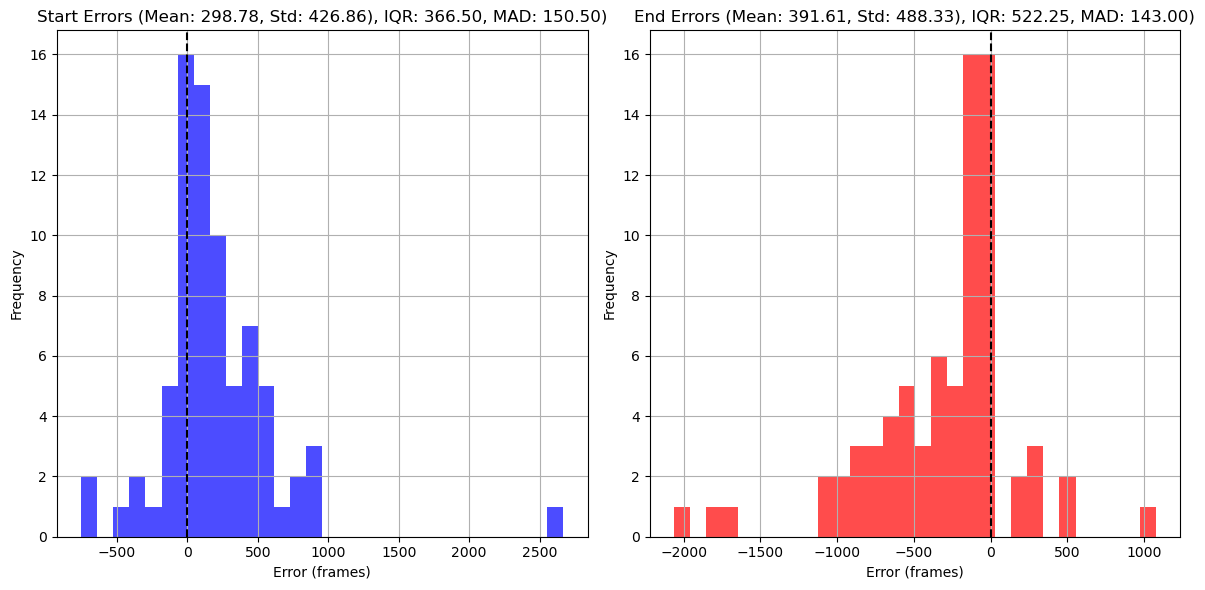

Average Start Errors by Phase:
Phase 0: 162.08333333333334
Phase 1: 333.5
Phase 2: 482.95238095238096
Phase 3: 182.27272727272728

Average End Errors by Phase:
Phase 0: 543.625
Phase 1: 407.9
Phase 2: 377.76190476190476
Phase 3: 56.72727272727273

Match Results:
Phase 0: {'match': 22, 'mismatch': 3, 'percent': 88.0}
Phase 1: {'match': 13, 'mismatch': 12, 'percent': 52.0}
Phase 2: {'match': 14, 'mismatch': 11, 'percent': 56.00000000000001}
Phase 3: {'match': 11, 'mismatch': 7, 'percent': 61.111111111111114}


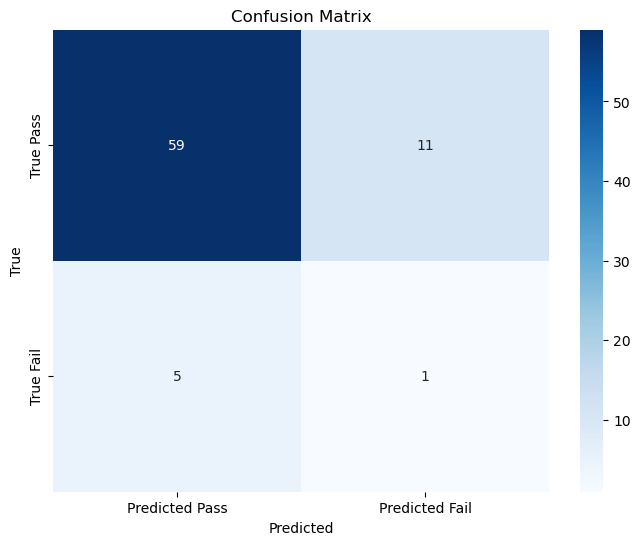

              precision    recall  f1-score   support

        Pass       0.92      0.84      0.88        70
        Fail       0.08      0.17      0.11         6

    accuracy                           0.79        76
   macro avg       0.50      0.50      0.50        76
weighted avg       0.86      0.79      0.82        76

number of missing phases 17


In [9]:
#best hyperparameters found:
holdout_labels, holdout_fps_list, holdout_model_outputs = get_data("/code/jjiang23/pathml/aim2_balance/processed_files/holdout_set.txt", frame_aware=True)

best_config = {
    'labels': holdout_labels,
    'arg_max_fun': thresholded_argmax(.3),
    'smoothing_function': majority_vote_past,
    'smoothing_window': 60,
    'timestamp_window': 5,
    'fps_list': holdout_fps_list,
    'leeway': 20,
    'model_outputs': holdout_model_outputs,  # Use the precomputed model outputs
}
(accuracy, f1, precision, recall), pred_labels, missing_info= run_experiment(best_config)
print("number of missing phases", len(missing_info))

In [ ]:
pred_labels[2]

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,


In [ ]:
features, labels, fps_list = get_dino_dataset("/code/jjiang23/pathml/aim2_balance/processed_files/eval_vid.txt")
labels = [label.tolist() for label in labels]

In [ ]:
features[0].shape, set(labels[0]), fps_list[0]

(torch.Size([1983, 1024]), {0, 1, 2, 3, 4}, np.float64(29.743884604327338))

In [ ]:
import pandas as pd
# FrameIndex,Label,Value
# 0,Ema Prediction,nonphase
# 0,Truth,nonphase
df = []

for i,(pred, label) in enumerate(zip(preds[0], labels[0])):
    df.append({'FrameIndex': i, 'Label': 'Dino Prediction', 'Value': pred})
    df.append({'FrameIndex': i, 'Label': 'Truth', 'Value': label})
video_labels = pd.DataFrame(df)
video_labels.to_csv('/code/jjiang23/pathml/aim2_balance/processed_files/dino_eval_labels.csv', index=False)

NameError: name 'preds' is not defined